In [1]:
## load library
from pycaret.classification import *

In [2]:
## load dataset
import pandas as pd
df = pd.read_csv("vgsales.csv")

In [3]:
## EDA
print(f"Cek 5 data teratas \n {df.head()} \n")

print(f"Cek tipe data \n {df.dtypes} \n")

print(f"Cek missing values \n {df.isnull().sum()}")

Cek 5 data teratas 
    Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37   

Cek tipe data 
 Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publis

In [4]:
## handle missing values
df["Year"] = df["Year"].fillna(df["Year"].median()) # Median
df["Publisher"] = df["Publisher"].fillna(df["Publisher"].mode()[0]) # Median

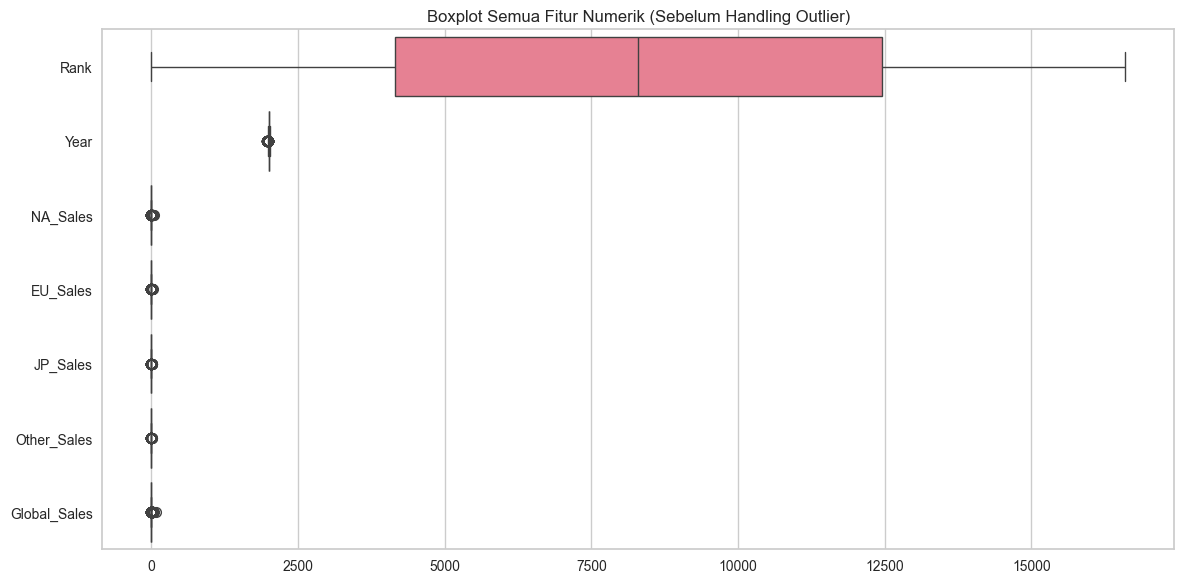

Jumlah outlier per kolom sebelum handling:
Rank: 0
Year: 136
NA_Sales: 1145
EU_Sales: 1506
JP_Sales: 1909
Other_Sales: 1199
Global_Sales: 1266


In [5]:
## Cek outlier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- Pilih kolom numerik ---
num_cols = df.select_dtypes(include="number").columns

# --- 0️⃣ Convert kolom ke numeric (handle string / unknown) ---
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid -> NaN

# Optional: isi NaN dengan median supaya bisa cek outlier
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 1️⃣ Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# 2️⃣ Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 2.5 * IQR
    upper = Q3 + 2.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")



Jumlah outlier per kolom setelah handling:
Rank: 0
Year: 0
NA_Sales: 0
EU_Sales: 0
JP_Sales: 0
Other_Sales: 0
Global_Sales: 0


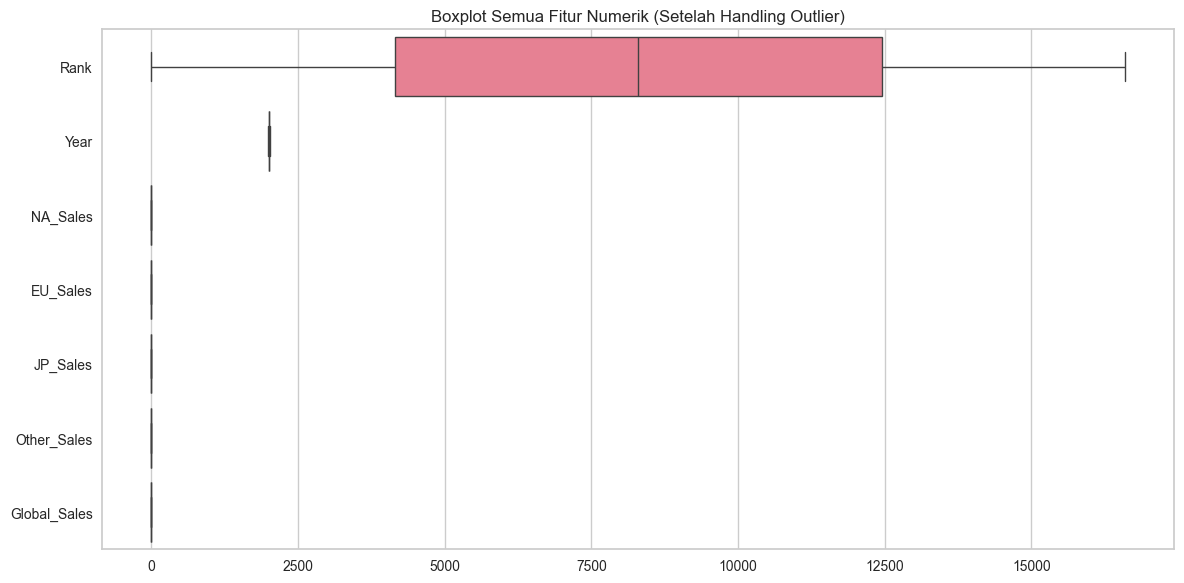

In [6]:
# handle outlier
import numpy as np
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 3️⃣ Handle outlier (opsi: 'remove', 'cap', 'robust')
strategy = 'cap'  # ganti sesuai kebutuhan
df_handled = df.copy()

for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if strategy == 'remove':
        df_handled = df_handled[(df_handled[col] >= lower) & (df_handled[col] <= upper)]
    elif strategy == 'cap':
        df_handled[col] = np.where(df_handled[col] < lower, lower,
                                   np.where(df_handled[col] > upper, upper, df_handled[col]))
    elif strategy == 'robust':
        scaler = RobustScaler()
        df_handled[num_cols] = scaler.fit_transform(df_handled[num_cols])
        break  # keluar dari loop setelah scaling

# 4️⃣ Hitung ulang outlier setelah handling
outlier_summary_after = {}
for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_handled[col] < lower) | (df_handled[col] > upper)).sum()
    outlier_summary_after[col] = outliers

print("\nJumlah outlier per kolom setelah handling:")
for k, v in outlier_summary_after.items():
    print(f"{k}: {v}")

# 5️⃣ Visualisasi boxplot setelah handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_handled[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Setelah Handling Outlier)")
plt.tight_layout()
plt.show()


In [7]:
# Setup
setup(
    df_handled,
    train_size=0.2,
    target="Genre"
)

,Description,Value
0,Session id,1389
1,Target,Genre
2,Target type,Multiclass
3,Target mapping,"Action: 0, Adventure: 1, Fighting: 2, Misc: 3, Platform: 4, Puzzle: 5, Racing: 6, Role-Playing: 7, Shooter: 8, Simulation: 9, Sports: 10, Strategy: 11"
4,Original data shape,"(16598, 11)"
5,Transformed data shape,"(16598, 11)"
6,Transformed train set shape,"(3319, 11)"
7,Transformed test set shape,"(13279, 11)"
8,Numeric features,7
9,Categorical features,3


In [8]:
# compare model
best_model = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,22:52:25
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.2516,0.0000,0.2516,0.1659,0.1702,0.1006,0.1232,0.0170
rf,Random Forest Classifier,0.2356,0.7018,0.2356,0.6606,0.2779,0.1834,0.2116,0.0840
qda,Quadratic Discriminant Analysis,0.2227,0.0000,0.2227,0.8497,0.2609,0.1558,0.2682,0.0170
lr,Logistic Regression,0.2145,0.0000,0.2145,0.3046,0.2115,0.1288,0.1350,0.5410
et,Extra Trees Classifier,0.2106,0.7072,0.2106,0.8141,0.2761,0.1671,0.2618,0.0690
dt,Decision Tree Classifier,0.2028,0.5869,0.2028,0.9421,0.2792,0.1611,0.2941,0.0210
gbc,Gradient Boosting Classifier,0.2028,0.0000,0.2028,0.9421,0.2792,0.1611,0.2941,0.5760
lda,Linear Discriminant Analysis,0.2010,0.0000,0.2010,0.9354,0.2767,0.1594,0.2910,0.0180
dummy,Dummy Classifier,0.1998,0.5000,0.1998,0.0399,0.0665,0.0000,0.0000,0.0200
ada,Ada Boost Classifier,0.1940,0.0000,0.1940,0.4077,0.1611,0.0906,0.2087,0.0470


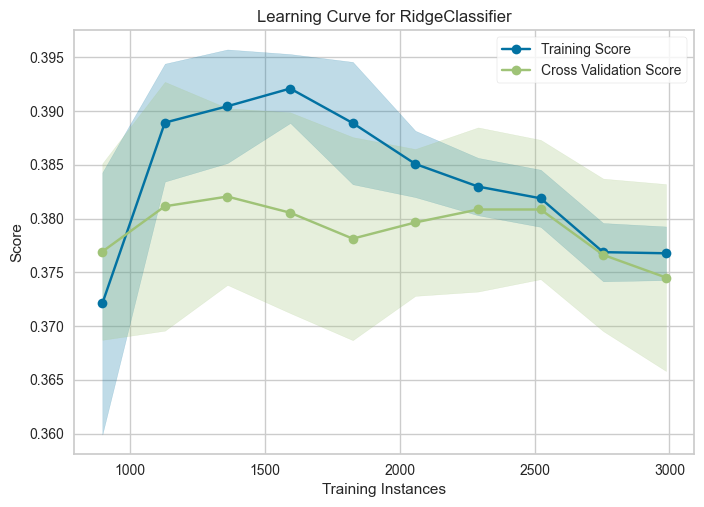

In [9]:
# learning
plot_model(best_model, plot="learning")

In [10]:
# tuning model
tuned_model = tune_model(best_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.2801,0.0000,0.2801,0.1999,0.1920,0.1343,0.1632
1,0.2681,0.0000,0.2681,0.1630,0.1831,0.1205,0.1456
2,0.2289,0.0000,0.2289,0.1318,0.1527,0.0748,0.0899
3,0.2500,0.0000,0.2500,0.1727,0.1733,0.0975,0.1217
4,0.2711,0.0000,0.2711,0.1584,0.1835,0.1257,0.1510
5,0.2500,0.0000,0.2500,0.1952,0.1810,0.0977,0.1225
6,0.2741,0.0000,0.2741,0.1798,0.1860,0.1296,0.1581
7,0.2560,0.0000,0.2560,0.1282,0.1607,0.1105,0.1299
8,0.2229,0.0000,0.2229,0.2135,0.1530,0.0748,0.0866


Fitting 10 folds for each of 10 candidates, totalling 100 fits


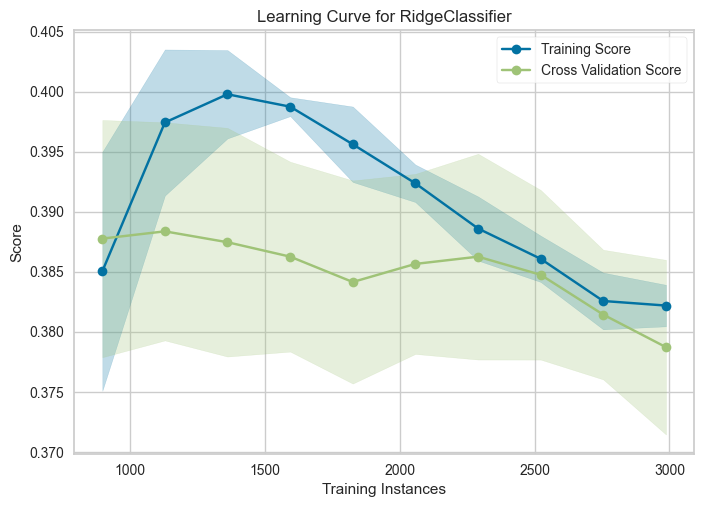

In [11]:
# evaluasi
plot_model(tuned_model, plot="learning")

In [12]:
pred = predict_model(best_model)
pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.2574,0,0.2574,0.1771,0.1707,0.1071,0.1313


,Rank,Name,Platform,Year,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre,prediction_label
7799,7801.0,DanceMasters,X360,2010.0,Konami Digital Entertainment,0.15,0.020,0.02,0.01,0.190,Misc,Action
13152,13154.0,Reel Fishing: The Great Outdoors,PSP,2006.0,Natsume,0.05,0.000,0.00,0.00,0.050,Sports,Action
9274,9276.0,MotoGP '06,X360,2006.0,THQ,0.11,0.010,0.00,0.01,0.140,Racing,Action
13234,13236.0,Ms Saga: A New Dawn,PS2,2005.0,Namco Bandai Games,0.02,0.020,0.00,0.01,0.050,Role-Playing,Action
6345,6347.0,Shadow Man,N64,1999.0,Acclaim Entertainment,0.18,0.080,0.00,0.01,0.270,Action,Action
...,...,...,...,...,...,...,...,...,...,...,...,...
16070,16073.0,East India Company,PC,2009.0,Paradox Interactive,0.01,0.000,0.00,0.00,0.010,Strategy,Action
9039,9041.0,Asphalt: Urban GT 2,DS,2006.0,Ubisoft,0.09,0.040,0.00,0.01,0.140,Racing,Action
8853,8855.0,Bakugan Battle Brawlers: Defenders of the Core,PSP,2010.0,Activision,0.09,0.040,0.00,0.03,0.150,Action,Action
793,795.0,Finding Nemo,PS2,2003.0,THQ,0.60,0.275,0.05,0.10,1.085,Action,Action
